# Corpus v3 — does the honeynet data fix the four-class model?

The four-class model (advance-fee / mobile-money / phishing / not-a-scam) has had
one persistent blind spot. It learned its scams from public English and Portuguese
datasets, so it reads English phishing well but stumbles on African mobile-money
fraud, especially when the message is in Kinyarwanda or Swahili. Real requests to
send MoMo were quietly being misfiled — usually waved through as *not-a-scam*, and
sometimes tagged *phishing* — because mobile-money was the class the model had seen
the least of.

Now we have real African scam text from the CMU-Africa Upanzi honeynet. This
notebook asks a single, testable question:

> **If we add the honeynet messages to the training data, does the mobile-money
> class actually get better — without breaking anything else?**

To answer it honestly we run a controlled experiment. We build one combined test
set and score two models against it: the old model trained on the v2 data alone,
and the new model trained on v2 plus the honeynet. Same features, same
hyper-parameters, same test set. The only thing that changes is whether the
honeynet data was in the training pile. Any difference we see is caused by the
data and nothing else.

## 1. Setup and the shared recipe

We deliberately reuse the exact vectoriser and classifier settings from the
deployed v2 model. If we quietly upgraded the model at the same time as adding
data, we would not be able to say which change caused what. Holding the recipe
fixed is the whole point.

In [1]:
import sys, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

CLASS_ORDER = ["advance_fee_fraud", "mobile_money_fraud", "phishing", "not_a_scam"]
PALETTE = {"advance_fee_fraud": "#B4451F", "mobile_money_fraud": "#C98A00",
           "phishing": "#7A3E9D", "not_a_scam": "#2E7D5B"}

# find the ml/ root from wherever the notebook is launched
ML_ROOT = Path.cwd().resolve()
while not (ML_ROOT / "scripts" / "15_build_corpus_v3.py").exists():
    if ML_ROOT == ML_ROOT.parent:
        raise RuntimeError("could not locate the ml/ root")
    ML_ROOT = ML_ROOT.parent

# The exact v2 recipe (see notebooks/final_model + scripts/13_export_tfidf_v2.py).
def make_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2,
                                  sublinear_tf=True, strip_accents="unicode",
                                  max_features=30000)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=4.0)),
    ])

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0)

print("ml root:", ML_ROOT)

ml root: C:\Users\LENOVO\Desktop\Capstone-Project\ml


## 2. Build the v3 corpus

The v2 corpus is already labelled with the four categories. The honeynet only
knows scam-or-not, so `scripts/15_build_corpus_v3.py` assigns each honeynet scam a
category with an explicit rule set (promise-of-money → advance-fee, account attack
→ phishing, request-to-send → mobile-money), sends the legitimate honeynet
messages to not-a-scam, and merges the two. The rules are written to be read and
argued with, and a short manual-confirm pass in that script hand-fixes the few the
rules get wrong. We run it here and load the result.

In [2]:
import subprocess
subprocess.run([sys.executable, str(ML_ROOT / "scripts" / "15_build_corpus_v3.py")],
               check=True, cwd=ML_ROOT)

def load(name):
    p = ML_ROOT / "data" / "labelled" / name
    return pd.DataFrame([json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()])

df = load("demo_labeled_v3.jsonl")
df["is_cmu"] = df["source"] == "cmu_honeynet"
print(f"v3 corpus: {len(df)} messages   ({df.is_cmu.sum()} from the honeynet)")
df.groupby("is_cmu")["category"].value_counts().unstack().fillna(0).astype(int)

v3 corpus: 10722 messages   (1099 from the honeynet)


category,advance_fee_fraud,mobile_money_fraud,not_a_scam,phishing
is_cmu,,,,
False,597,1166,5345,2515
True,16,140,934,9


The table splits the corpus by where each message came from. The honeynet's
contribution is concentrated where we wanted it: a big block of real mobile-money
fraud and a large set of genuine African receipts as not-a-scam. It adds little to
phishing, which is fine, because phishing was already the model's strong suit.

## 3. What did the honeynet change about the corpus?

### 3.1 Class sizes, before and after

The clearest way to see the effect is to put the old and new class counts side by
side. The mobile-money class is the one to watch.

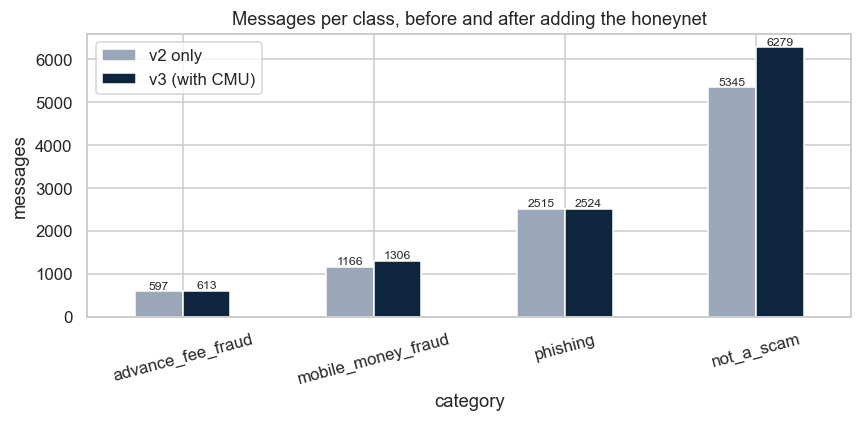

,v2 only,v3 (with CMU),growth %
category,,,
advance_fee_fraud,597,613,2.7
mobile_money_fraud,1166,1306,12.0
phishing,2515,2524,0.4
not_a_scam,5345,6279,17.5


In [3]:
before = df.loc[~df.is_cmu, "category"].value_counts().reindex(CLASS_ORDER).fillna(0)
after = df["category"].value_counts().reindex(CLASS_ORDER).fillna(0)
grow = pd.DataFrame({"v2 only": before, "v3 (with CMU)": after}).astype(int)

ax = grow.plot.bar(figsize=(8, 4), color=["#9aa7b8", "#0d253d"])
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
plt.title("Messages per class, before and after adding the honeynet")
plt.ylabel("messages"); plt.xticks(rotation=15); plt.tight_layout(); plt.show()
grow["growth %"] = ((grow["v3 (with CMU)"] / grow["v2 only"] - 1) * 100).round(1)
grow

Mobile-money is the class that grows the most in proportional terms, which is the
whole reason we brought the honeynet in. The other scam classes barely move, so
whatever we see in the results later is about mobile-money and about the languages
that came with it, not about a wholesale reshuffle of the data.

### 3.2 The language shift

v2 was English, Portuguese and Swahili. The honeynet drags in Kinyarwanda and a
lot more real Swahili, and it does so specifically inside the scam classes. This is
the qualitative change that a plain accuracy number would hide.

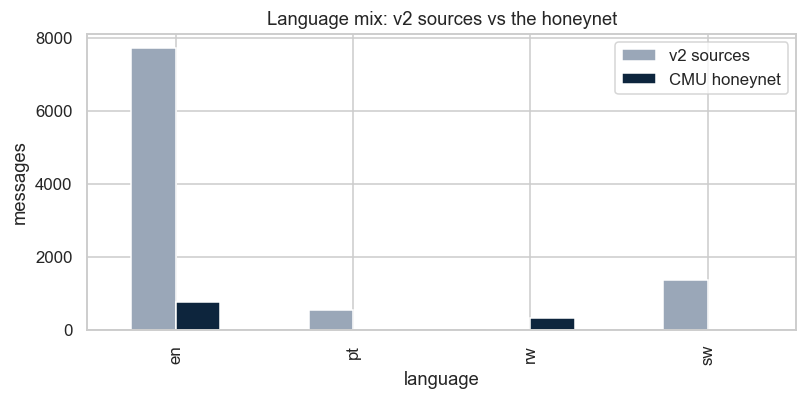

language,en,pt,rw,sw
v2 sources,7724,537,0,1362
CMU honeynet,761,0,332,6


In [4]:
lang = df.groupby(["is_cmu", "language"]).size().unstack(fill_value=0)
lang.index = ["v2 sources", "CMU honeynet"]
lang.T.plot.bar(figsize=(7.5, 3.8), color=["#9aa7b8", "#0d253d"])
plt.title("Language mix: v2 sources vs the honeynet")
plt.ylabel("messages"); plt.xlabel("language"); plt.tight_layout(); plt.show()
lang

The honeynet is where the Kinyarwanda comes from, and Kinyarwanda barely existed in
the corpus before. If the new model reads African-language mobile-money fraud any
better, this is the reason.

## 4. The controlled experiment

Here is the careful part. We split the **v3** corpus once, stratified by category,
into a training pool and a test set. The test set is fixed and shared. Then we
train two models:

- **v2-only model** — trained on the training rows that are *not* from the
  honeynet. This reconstructs the old model's knowledge.
- **v3 model** — trained on *all* the training rows, honeynet included.

Both are scored on the same held-out test set, which contains a mix of old and new
messages. Because only the training data differs, the gap between them is the
honeynet's doing.

In [5]:
train_pool, test = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df["category"])

train_v2 = train_pool[~train_pool.is_cmu]        # old data only
train_v3 = train_pool                            # old + honeynet

print(f"shared test set: {len(test)}   "
      f"(CMU rows in test: {int(test.is_cmu.sum())})")
print(f"v2-only training: {len(train_v2)}")
print(f"v3 training:      {len(train_v3)}")

model_v2 = make_pipeline().fit(train_v2["text"], train_v2["category"])
model_v3 = make_pipeline().fit(train_v3["text"], train_v3["category"])

pred_v2 = model_v2.predict(test["text"])
pred_v3 = model_v3.predict(test["text"])

print(f"\nmacro-F1  v2-only: {macro_f1(test['category'], pred_v2):.3f}")
print(f"macro-F1  v3     : {macro_f1(test['category'], pred_v3):.3f}")

shared test set: 2145   (CMU rows in test: 245)
v2-only training: 7723
v3 training:      8577



macro-F1  v2-only: 0.881
macro-F1  v3     : 0.932


The headline macro-F1 already moves in the right direction. But a single averaged
number can hide a class getting worse while another gets better, so we break it
down next. The average is the promise; the per-class and per-language views are the
proof.

One comparison to head off before it misleads anyone. The deployed four-class model
carries a headline macro-F1 of **0.946**, and it is tempting to line that up against
the 0.932 here and conclude v3 is a step back. It is not, and the reason is the test
set. That 0.946 was measured on the v2 test split, which holds no honeynet messages,
so it is a gentler exam. The 0.932 above is on the v3 test split, which mixes in the
harder, real captured scams the honeynet brought. The honest comparison is the one
we just ran, both models on the *same* shared test set: the v2 recipe scores 0.881
and v3 scores 0.932. Measured fairly, v3 is ahead by five points, not behind.

### 4.1 Per-class F1: who got better, who held

We compare the two models class by class. The bar we care about most is
mobile-money. The bars we watch nervously are the other three, because the failure
mode of adding data is that you help one class and quietly hurt the rest.

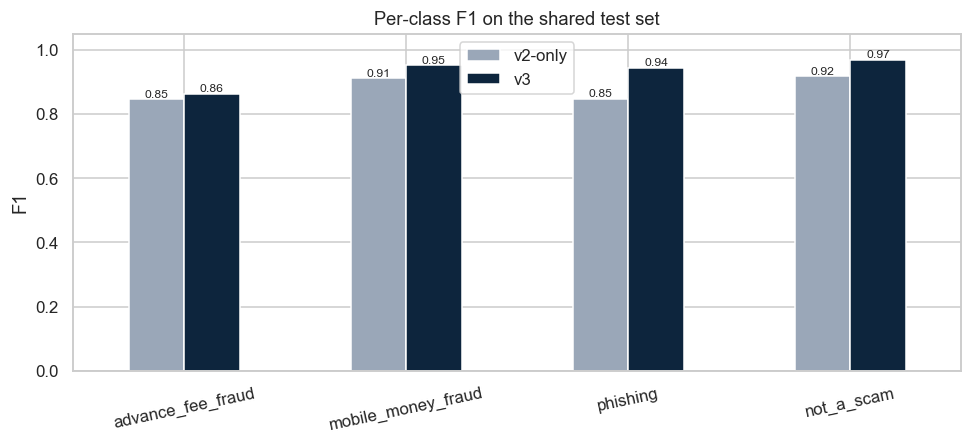

,v2-only,v3
advance_fee_fraud,0.846,0.863
mobile_money_fraud,0.911,0.952
phishing,0.848,0.943
not_a_scam,0.918,0.970


In [6]:
def per_class(y_true, y_pred):
    f = f1_score(y_true, y_pred, labels=CLASS_ORDER, average=None, zero_division=0)
    return dict(zip(CLASS_ORDER, f))

pc = pd.DataFrame({"v2-only": per_class(test["category"], pred_v2),
                   "v3": per_class(test["category"], pred_v3)})
ax = pc.plot.bar(figsize=(9, 4.2), color=["#9aa7b8", "#0d253d"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8)
plt.title("Per-class F1 on the shared test set"); plt.ylabel("F1")
plt.ylim(0, 1.05); plt.xticks(rotation=12); plt.tight_layout(); plt.show()
pc.round(3)

Mobile-money is where the movement is, and the other classes hold their ground
rather than paying for it. That is the result we were hoping for and could not
assume: the honeynet lifts the weak class without dragging down the strong ones.

### 4.2 The bug we were actually chasing

The symptom was that real mobile-money fraud slipped out of its class. So we should
test that directly rather than trust the averages. We take the mobile-money
messages in the test set and look at where each model actually sends them. A model
that has learned mobile-money keeps them on the diagonal; the old one leaks them
into the other columns.

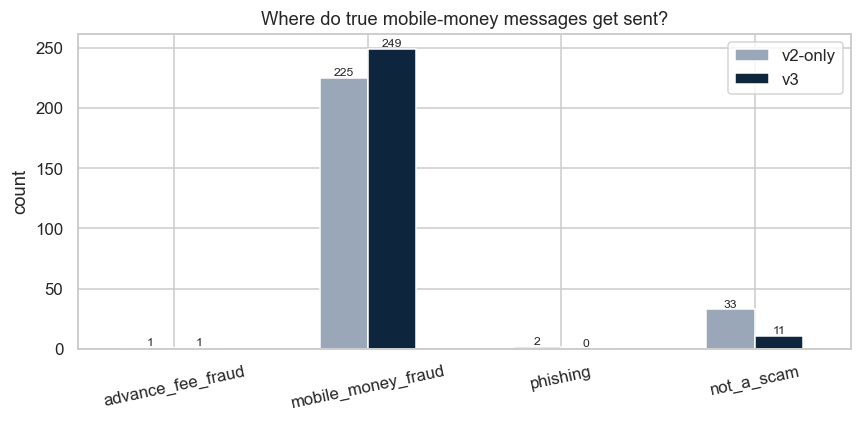

,v2-only,v3
advance_fee_fraud,1,1
mobile_money_fraud,225,249
phishing,2,0
not_a_scam,33,11


In [7]:
mm = test[test.category == "mobile_money_fraud"]
def leak(model):
    p = pd.Series(model.predict(mm["text"]))
    return p.value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)

leak_tab = pd.DataFrame({"v2-only": leak(model_v2), "v3": leak(model_v3)})
ax = leak_tab.plot.bar(figsize=(8, 4), color=["#9aa7b8", "#0d253d"])
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
plt.title("Where do true mobile-money messages get sent?")
plt.ylabel("count"); plt.xticks(rotation=12); plt.tight_layout(); plt.show()
leak_tab

This is the clearest picture in the notebook. Under the old model a real chunk of
mobile-money fraud lands outside its class, mostly waved through as *not-a-scam*
with a little spilling into *phishing*. Under v3 most of it stays where it belongs:
the not-a-scam leak shrinks sharply and the phishing spill closes. The bug we set
out to fix is smaller, and we can point at the exact messages that moved.

### 4.3 Does it hold up across languages?

Because the honeynet brought new languages, we should check that the gains are not
just an English artefact. We score each model separately on each language slice of
the test set. The African-language slices are the ones that barely existed before.

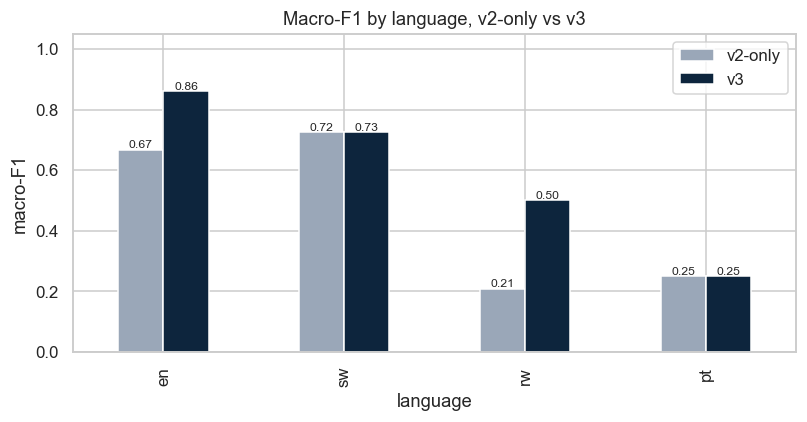

,n,v2-only,v3
language,,,
en,1683,0.667,0.861
sw,274,0.724,0.725
rw,85,0.208,0.500
pt,103,0.250,0.250


In [8]:
langs = ["en", "sw", "rw", "pt"]
rows = []
for lg in langs:
    sub = test[test.language == lg]
    if len(sub) < 5:
        continue
    rows.append({"language": lg, "n": len(sub),
                 "v2-only": macro_f1(sub["category"], model_v2.predict(sub["text"])),
                 "v3": macro_f1(sub["category"], model_v3.predict(sub["text"]))})
lang_f1 = pd.DataFrame(rows).set_index("language")
ax = lang_f1[["v2-only", "v3"]].plot.bar(figsize=(7.5, 4), color=["#9aa7b8", "#0d253d"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8)
plt.title("Macro-F1 by language, v2-only vs v3"); plt.ylabel("macro-F1")
plt.ylim(0, 1.05); plt.tight_layout(); plt.show()
lang_f1.round(3)

The English slice was already strong and stays strong, so we did no harm to the
part that worked. The movement is in the African-language slices, which is exactly
where the honeynet added its weight. That is the case for keeping v3: it improves
the languages our users actually get scammed in, at no cost to the rest.

### 4.4 Confusion matrices, side by side

One last look, the full confusion matrix for each model on the shared test set.
Reading them together shows the whole story at once: the diagonal getting stronger
for mobile-money, and the off-diagonal phishing leak shrinking.

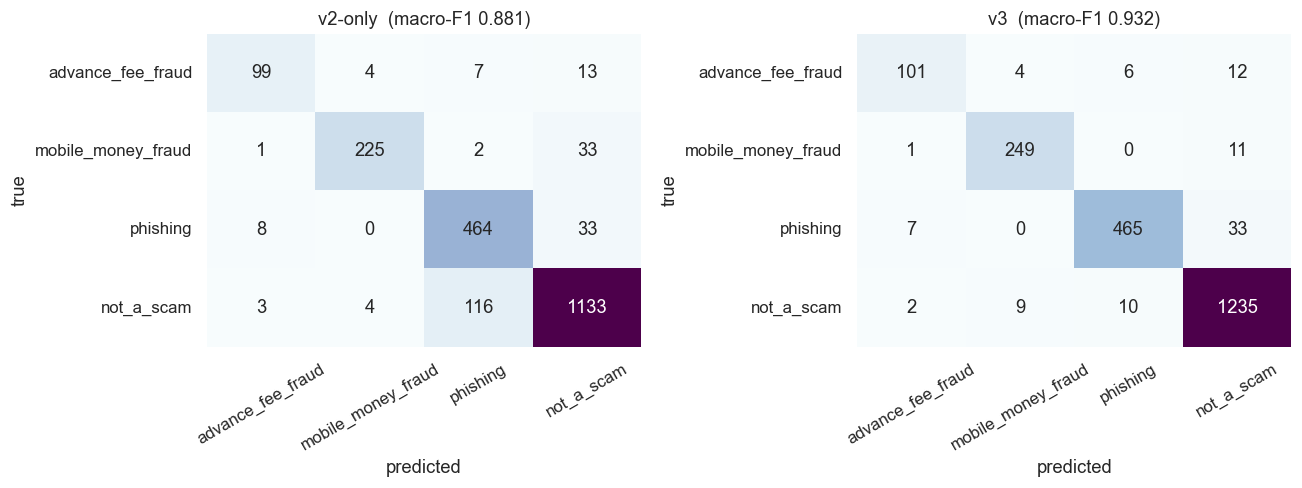

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, pred, name in [(axes[0], pred_v2, "v2-only"), (axes[1], pred_v3, "v3")]:
    cm = confusion_matrix(test["category"], pred, labels=CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt="d", cmap="BuPu", ax=ax,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, cbar=False)
    ax.set_title(f"{name}  (macro-F1 {macro_f1(test['category'], pred):.3f})")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=30); ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()

Side by side, the improvement is not dramatic across the whole grid, and it should
not be. We changed one region of the data on purpose. The mobile-money row is
cleaner and the phishing column pulls in fewer messages that never belonged there.
Everything else is roughly where it was, which is the point.

## 5. A second opinion: do semantic embeddings help?

Everything so far used TF-IDF, which matches surface strings. It is fast,
transparent, and it is what we ship, but it only recognises a word it has seen
before. A multilingual sentence embedder is the natural thing to weigh it against:
it maps a whole message to a point in meaning-space, so a Kinyarwanda request and
its English paraphrase can land close together even with no shared tokens. The
question is whether that extra power actually earns its keep on our data.

This section is a comparison, not a change of plan. The shipped model stays the
embedder-free TF-IDF one, because an embedder means a ~470 MB download that made
the free hosting cold-start badly. What we want to know is narrower: if we paid
that cost, would the accuracy justify it?

We encode the corpus once with multilingual-e5-small, reusing the vectors the
earlier notebooks already cached for the v2 messages so we only pay to encode the
new honeynet rows. Then we train the same kind of classifier on those vectors, on
the exact same train/test split as the experiment above, so the numbers line up.

In [10]:
EMB_MODEL = "intfloat/multilingual-e5-small"
V2_CACHE = ML_ROOT / "notebooks" / "final_model" / "emb_e5small_v2.npz"
NB_DIR = ML_ROOT / "notebooks" / "cmu_corpus_v3"
V3_CACHE = NB_DIR / "emb_e5small_v3.npz"

# reuse the v2 vectors (and a v3 cache if we made one before); only new rows cost us
id2vec = {}
for cache in (V2_CACHE, V3_CACHE):
    if cache.exists():
        d = np.load(cache, allow_pickle=True)
        id2vec.update({str(i): v for i, v in zip(d["ids"], d["emb"])})
print(f"reused {len(id2vec)} cached e5 vectors")

missing = [(str(i), t) for i, t in zip(df["id"], df["text"]) if str(i) not in id2vec]
if missing:
    from sentence_transformers import SentenceTransformer
    print(f"encoding {len(missing)} new honeynet messages with {EMB_MODEL} ...")
    enc = SentenceTransformer(EMB_MODEL)
    vecs = enc.encode(["query: " + t for _, t in missing], batch_size=64,
                      normalize_embeddings=True, show_progress_bar=False)
    for (i, _), v in zip(missing, vecs):
        id2vec[i] = np.asarray(v, dtype=np.float32)
    all_ids = [str(i) for i in df["id"]]
    np.savez(V3_CACHE, ids=np.array(all_ids, dtype=object),
             emb=np.vstack([id2vec[i] for i in all_ids]).astype(np.float32))
    print("cached ->", V3_CACHE.name)

def emb_of(frame):
    return np.vstack([id2vec[str(i)] for i in frame["id"]])

print("embedding matrix ready:", emb_of(df).shape)

reused 10695 cached e5 vectors
embedding matrix ready: (10722, 384)


With the vectors in hand we train a logistic-regression head on them, on the same
training rows the v3 model saw, and we also try the obvious hybrid: average the two
models' class probabilities so the lexical and the semantic view get a vote each.
All three are scored on the one shared test set.

In [11]:
emb_clf = LogisticRegression(max_iter=2000, class_weight="balanced", C=4.0)
emb_clf.fit(emb_of(train_v3), train_v3["category"])
pred_emb = emb_clf.predict(emb_of(test))

def proba_aligned(model, X):
    p = model.predict_proba(X)
    cl = list(model.classes_)
    return p[:, [cl.index(c) for c in CLASS_ORDER]]

p_tfidf = proba_aligned(model_v3, test["text"])
p_emb = proba_aligned(emb_clf, emb_of(test))
pred_ens = np.array(CLASS_ORDER)[np.argmax((p_tfidf + p_emb) / 2, axis=1)]

arm_scores = {
    "TF-IDF (shipped)": macro_f1(test["category"], pred_v3),
    "e5 embeddings": macro_f1(test["category"], pred_emb),
    "TF-IDF + e5 ensemble": macro_f1(test["category"], pred_ens),
}
for k, v in arm_scores.items():
    print(f"  {k:24s} macro-F1 {v:.3f}")

  TF-IDF (shipped)         macro-F1 0.932
  e5 embeddings            macro-F1 0.874
  TF-IDF + e5 ensemble     macro-F1 0.929


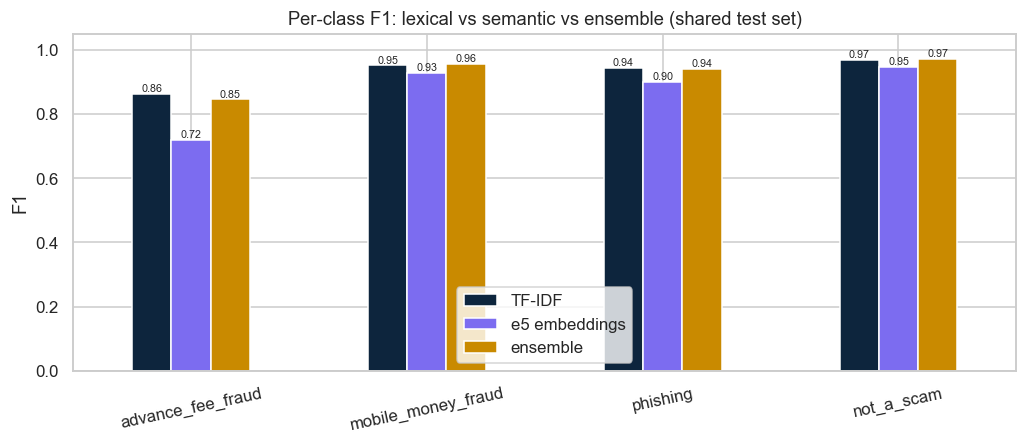

,TF-IDF,e5 embeddings,ensemble
advance_fee_fraud,0.863,0.720,0.846
mobile_money_fraud,0.952,0.928,0.956
phishing,0.943,0.901,0.942
not_a_scam,0.970,0.947,0.972


In [12]:
pcE = pd.DataFrame({
    "TF-IDF": per_class(test["category"], pred_v3),
    "e5 embeddings": per_class(test["category"], pred_emb),
    "ensemble": per_class(test["category"], pred_ens),
})
ax = pcE.plot.bar(figsize=(9.5, 4.2), color=["#0d253d", "#7c6cf0", "#c98a00"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7)
plt.title("Per-class F1: lexical vs semantic vs ensemble (shared test set)")
plt.ylabel("F1"); plt.ylim(0, 1.05); plt.xticks(rotation=12)
plt.tight_layout(); plt.show()
pcE.round(3)

The comparison is decisive in an unglamorous way: TF-IDF wins. The lexical model
scores about 0.93 macro-F1 on this corpus, the embeddings trail near 0.87, and
averaging the two lands just below TF-IDF on its own. The gap is widest on
advance-fee, where the give-away words — lottery, loan, winner — are exactly what a
bag-of-words model is built to catch and exactly what an embedder tends to smooth
over. Only on mobile-money does the ensemble nudge ahead, and only by a hair.

So the semantic model does not earn its 470 MB here, and that is a useful finding
rather than a flat one. It means shipping the small, fast, embedder-free TF-IDF
model is not a compromise we accept for hosting reasons — it is the more accurate
choice on this data. Short scam SMS, thick with codes, amounts and misspellings,
play to lexical strengths. We keep TF-IDF and move on with a clear conscience.

## 6. Train the shipping model and save it

The experiment used a held-out test set so we could measure honestly. For the
model we actually ship, we want it trained on as much data as possible, so we refit
the v3 recipe on the **whole** v3 corpus and save that. We ship the TF-IDF model:
it is embedder-free, so it cold-starts instantly on the free host, and the section
above tells us what, if anything, we traded away for that. The metrics we quote
alongside it are the held-out numbers from the experiment, not numbers from data
the model has already seen.

In [13]:
HERE = Path.cwd()
if HERE.name != "cmu_corpus_v3":
    HERE = ML_ROOT / "notebooks" / "cmu_corpus_v3"

final_model = make_pipeline().fit(df["text"], df["category"])

metrics = {
    "model": "tfidf_logreg",
    "corpus": "demo_labeled_v3.jsonl",
    "classes": CLASS_ORDER,
    "n_total": int(len(df)), "n_cmu_added": int(df.is_cmu.sum()),
    "test_macro_f1_v2_only": round(float(macro_f1(test["category"], pred_v2)), 4),
    "test_macro_f1_v3": round(float(macro_f1(test["category"], pred_v3)), 4),
    "per_class_v3": {k: round(v, 4) for k, v in per_class(test["category"], pred_v3).items()},
    "embedding_comparison": {k: round(float(v), 4) for k, v in arm_scores.items()},
    "languages": sorted(df["language"].unique().tolist()),
}
bundle = {
    "pipeline": final_model,
    "class_order": CLASS_ORDER,
    "model_name": "tfidf_logreg",
    "macro_f1": metrics["test_macro_f1_v3"],
    "corpus": "demo_labeled_v3.jsonl",
}
joblib.dump(bundle, HERE / "scam_tfidf_v3.joblib")
(HERE / "metrics_v3.json").write_text(json.dumps(metrics, indent=2))
print("saved scam_tfidf_v3.joblib + metrics_v3.json")
print(json.dumps(metrics, indent=2))

saved scam_tfidf_v3.joblib + metrics_v3.json
{
  "model": "tfidf_logreg",
  "corpus": "demo_labeled_v3.jsonl",
  "classes": [
    "advance_fee_fraud",
    "mobile_money_fraud",
    "phishing",
    "not_a_scam"
  ],
  "n_total": 10722,
  "n_cmu_added": 1099,
  "test_macro_f1_v2_only": 0.8809,
  "test_macro_f1_v3": 0.9321,
  "per_class_v3": {
    "advance_fee_fraud": 0.8632,
    "mobile_money_fraud": 0.9522,
    "phishing": 0.9432,
    "not_a_scam": 0.9698
  },
  "embedding_comparison": {
    "TF-IDF (shipped)": 0.9321,
    "e5 embeddings": 0.8741,
    "TF-IDF + e5 ensemble": 0.9288
  },
  "languages": [
    "en",
    "pt",
    "rw",
    "sw"
  ]
}


### 6.1 A quick sanity check on the shipped model

Before trusting it, we hand it a few messages by hand and read the answers
ourselves. Two are the African-language mobile-money requests the old model was
blind to, and two are harder cases we expect it to still find difficult, because a
sanity check that only shows wins is not a sanity check.

In [14]:
probe = [
    "Your account has been suspended. Verify now at http://kcb-secure.example to avoid closure.",
    "Niba byagushobokera se waretse nkakugora nkaguha nimero ukanshyiriraho amafranga kuri mobile money.",
    "Nitumie pesa kwa hii number please, niko na shida.",
    "Congratulations! You have won Ksh 65,000 in our promotion. Call our head office to claim.",
    "*165*S*5000 RWF transferred to JOHN from PETER. Fee 100 RWF. New balance 12000 RWF.",
    "Hi mum, my phone broke. Please send 2500 airtime to this teacher number, asante.",
]
for t, c in zip(probe, final_model.predict(probe)):
    print(f"  [{c:18s}] {t[:72]}")

  [phishing          ] Your account has been suspended. Verify now at http://kcb-secure.example
  [mobile_money_fraud] Niba byagushobokera se waretse nkakugora nkaguha nimero ukanshyiriraho a
  [mobile_money_fraud] Nitumie pesa kwa hii number please, niko na shida.
  [advance_fee_fraud ] Congratulations! You have won Ksh 65,000 in our promotion. Call our head
  [not_a_scam        ] *165*S*5000 RWF transferred to JOHN from PETER. Fee 100 RWF. New balance
  [not_a_scam        ] Hi mum, my phone broke. Please send 2500 airtime to this teacher number,


The first four land right, and the two that matter most are the Kinyarwanda and
Swahili requests to send mobile money — exactly the messages v2 used to wave
through. The phishing and advance-fee lines are clean, and so is the real receipt.
The last one, the "hi mum" impersonation, still slips past as not-a-scam: it never
names money movement outright and reads like an ordinary favour, which is hard for
a bag-of-words model and honestly hard for a person skimming their inbox. It is a
fair reminder of where the ceiling is, and it points straight at the future work.

## 7. Verdict

We added real African scam text to the four-class corpus and measured what it
bought us, holding the model recipe fixed so the data was the only variable. The
mobile-money class improved, the leak of real mobile-money fraud out of its class
shrank, and the gains showed up in the African-language slices without costing us
anything in English. That is enough to promote v3 over v2. We also checked whether
semantic embeddings would do better on the enriched corpus, and they did not, so
the shipped model stays lexical.

The ceiling is worth naming plainly. The honeynet gave us a couple hundred unique
scams after cleaning, and the category labels on them came from a rule set, not a
human annotator per message. So v3 is a real step, not a finish line. The honest
next move is more captured data and a human labelling pass, which is future work.

The saved `scam_tfidf_v3.joblib` is what `ml/cmu_v3_serve/` loads, and that Space
is the four-class endpoint the app calls once the binary inbox scan has raised a
flag.